# Data Preprocess

## Read Data

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

print("="*70)
print("ENHANCED DATA PREPROCESSING WITH NaN HANDLING")
print("="*70)

rainfall_path = 'Rainfall-Data.csv'
riverlevel_path = 'Riverlevel-Data.csv'

rainfall_df = pd.read_csv(rainfall_path, na_values='NaN')
riverlevel_df = pd.read_csv(riverlevel_path, na_values='NaN')

print("✓ Data loaded")
print(f"  Rainfall shape: {rainfall_df.shape}")
print(f"  River level shape: {riverlevel_df.shape}")

ENHANCED DATA PREPROCESSING WITH NaN HANDLING
✓ Data loaded
  Rainfall shape: (9008, 13)
  River level shape: (9008, 8)


## Parse DateTime and Sort

In [3]:
rainfall_df['DateTime'] = pd.to_datetime(rainfall_df['DateTime'], format='%Y-%m-%d %H')
riverlevel_df['DateTime'] = pd.to_datetime(riverlevel_df['DateTime'], format='%Y-%m-%d %H')

rainfall_df = rainfall_df.set_index('DateTime').sort_index()
riverlevel_df = riverlevel_df.set_index('DateTime').sort_index()


ANALYZING NaN VALUES


## NaN Handling

In [4]:
print("\n" + "="*70)
print("ANALYZING NaN VALUES")
print("="*70)

print("\nRainfall NaN percentage per station:")
rain_nan_pct = (rainfall_df.isnull().sum() / len(rainfall_df)) * 100
for col, pct in rain_nan_pct.items():
    print(f"  {col}: {pct:.1f}%")

print("\nRiver Level NaN percentage per station:")
river_nan_pct = (riverlevel_df.isnull().sum() / len(riverlevel_df)) * 100
for col, pct in river_nan_pct.items():
    print(f"  {col}: {pct:.1f}%")

print("\n" + "="*70)
print("REMOVING STATIONS WITH >80% NaN")
print("="*70)

rain_valid_cols = rain_nan_pct[rain_nan_pct < 80].index.tolist()
river_valid_cols = river_nan_pct[river_nan_pct < 80].index.tolist()

print(f"\nRainfall stations kept: {len(rain_valid_cols)}/{len(rainfall_df.columns)}")
print(f"Removed: {set(rainfall_df.columns) - set(rain_valid_cols)}")

print(f"\nRiver level stations kept: {len(river_valid_cols)}/{len(riverlevel_df.columns)}")
print(f"Removed: {set(riverlevel_df.columns) - set(river_valid_cols)}")

rainfall_df = rainfall_df[rain_valid_cols]
riverlevel_df = riverlevel_df[river_valid_cols]


ANALYZING NaN VALUES

Rainfall NaN percentage per station:
  Malabog: 1.7%
  Calsada: 10.5%
  Caguscos: 1.7%
  Bato: 1.6%
  Buhi: 1.6%
  Ombao: 1.6%
  Ocampo: 1.6%
  Camaligan: 1.6%
  Bagamelon: 1.6%
  Balongay: 100.0%
  Alanao: 82.7%
  Sipocot: 11.2%

River Level NaN percentage per station:
  Calsada: 8.7%
  Bato: 64.6%
  Buhi: 1.1%
  Ombao: 1.1%
  Camaligan: 1.1%
  Balongay: 100.0%
  Sipocot: 0.0%

REMOVING STATIONS WITH >80% NaN

Rainfall stations kept: 10/12
Removed: {'Alanao', 'Balongay'}

River level stations kept: 6/7
Removed: {'Balongay'}


## Generate Time Index

In [7]:
print("\n" + "="*70)
print("GENERATING TIME INDEX")
print("="*70)

full_index = pd.date_range(
    start=min(rainfall_df.index.min(), riverlevel_df.index.min()),
    end=max(rainfall_df.index.max(), riverlevel_df.index.max()),
    freq='H'
)

rainfall_df = rainfall_df.reindex(full_index)
riverlevel_df = riverlevel_df.reindex(full_index)

rainfall_df = rainfall_df.fillna(method='ffill').fillna(method='bfill').fillna(0)
riverlevel_df = riverlevel_df.fillna(method='ffill').fillna(method='bfill').fillna(0)

print(f"✓ Time index generated")
print(f"  Date range: {full_index.min()} to {full_index.max()}")
print(f"  Total hours: {len(full_index)}")


GENERATING TIME INDEX
✓ Time index generated
  Date range: 2024-10-19 01:00:00 to 2025-10-29 08:00:00
  Total hours: 9008


C:\Users\Selwyn Lao\AppData\Local\Temp\ipykernel_20804\1583676979.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_index = pd.date_range(
C:\Users\Selwyn Lao\AppData\Local\Temp\ipykernel_20804\1583676979.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  rainfall_df = rainfall_df.fillna(method='ffill').fillna(method='bfill').fillna(0)
C:\Users\Selwyn Lao\AppData\Local\Temp\ipykernel_20804\1583676979.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  riverlevel_df = riverlevel_df.fillna(method='ffill').fillna(method='bfill').fillna(0)


## Normalize

In [8]:
# Normalize
print("\n" + "="*70)
print("NORMALIZING DATA")
print("="*70)

rain_scaler = MinMaxScaler()
river_scaler = MinMaxScaler()

rainfall_norm = pd.DataFrame(
    rain_scaler.fit_transform(rainfall_df),
    index=rainfall_df.index,
    columns=rainfall_df.columns
)

riverlevel_norm = pd.DataFrame(
    river_scaler.fit_transform(riverlevel_df),
    index=riverlevel_df.index,
    columns=riverlevel_df.columns
)

print("✓ Data normalized")


NORMALIZING DATA
✓ Data normalized


## Nan Check

In [11]:
# CRITICAL: Final NaN check
print("\n" + "="*70)
print("FINAL NaN CHECK")
print("="*70)

final_rain_nan = rainfall_norm.isnull().sum().sum()
final_river_nan = riverlevel_norm.isnull().sum().sum()

print(f"Rainfall NaN count: {final_rain_nan}")
print(f"River level NaN count: {final_river_nan}")

if final_rain_nan > 0:
    print("⚠️  Forcing rainfall NaN to 0...")
    rainfall_norm = rainfall_norm.fillna(0)

if final_river_nan > 0:
    print("⚠️  Forcing river level NaN to 0...")
    riverlevel_norm = riverlevel_norm.fillna(0)

# Verify no infinities
if np.any(np.isinf(rainfall_norm.values)):
    print("⚠️  Found infinities in rainfall, replacing with 0...")
    rainfall_norm = rainfall_norm.replace([np.inf, -np.inf], 0)

if np.any(np.isinf(riverlevel_norm.values)):
    print("⚠️  Found infinities in river level, replacing with 0...")
    riverlevel_norm = riverlevel_norm.replace([np.inf, -np.inf], 0)

print("\n✅ DATA IS CLEAN - NO NaN OR INFINITIES")


FINAL NaN CHECK
Rainfall NaN count: 0
River level NaN count: 0

✅ DATA IS CLEAN - NO NaN OR INFINITIES


## Stats

In [12]:
print("\n" + "="*50)
print("RAINFALL NORMALIZED STATISTICS")
print("="*50)
print(rainfall_norm.describe())

print("\n" + "="*50)
print("RIVER LEVEL NORMALIZED STATISTICS")
print("="*50)
print(riverlevel_norm.describe())

print("\n" + "="*50)
print("NULL VALUES CHECK")
print("="*50)
print("Rainfall null values:")
print(rainfall_norm.isnull().sum())
print("\nRiver level null values:")
print(riverlevel_norm.isnull().sum())


RAINFALL NORMALIZED STATISTICS
           Malabog      Calsada     Caguscos         Bato         Buhi  \
count  9008.000000  9008.000000  9008.000000  9008.000000  9008.000000   
mean      0.010661     0.007344     0.005266     0.009703     0.006393   
std       0.048584     0.042533     0.032348     0.053318     0.035302   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.000000     0.000000     0.000000     0.000000     0.000000   
50%       0.000000     0.000000     0.000000     0.000000     0.000000   
75%       0.000000     0.000000     0.000000     0.000000     0.000000   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

             Ombao       Ocampo    Camaligan    Bagamelon      Sipocot  
count  9008.000000  9008.000000  9008.000000  9008.000000  9008.000000  
mean      0.005545     0.004344     0.005049     0.005118     0.007057  
std       0.034500     0.027904     0.031847     0.028545     0.037280  
min      

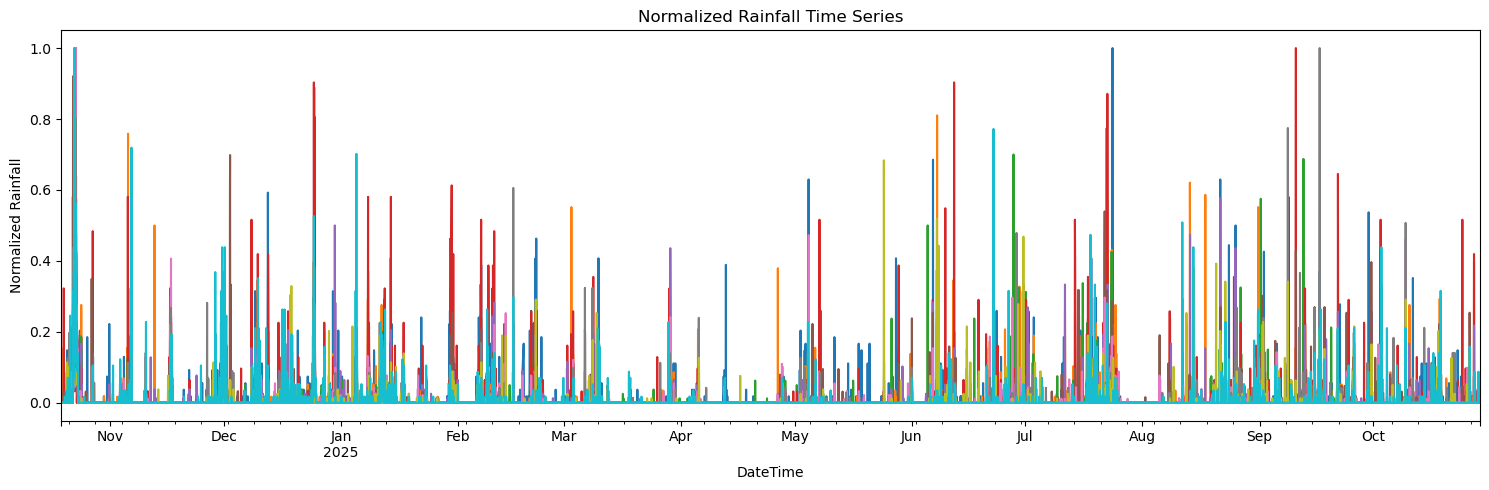

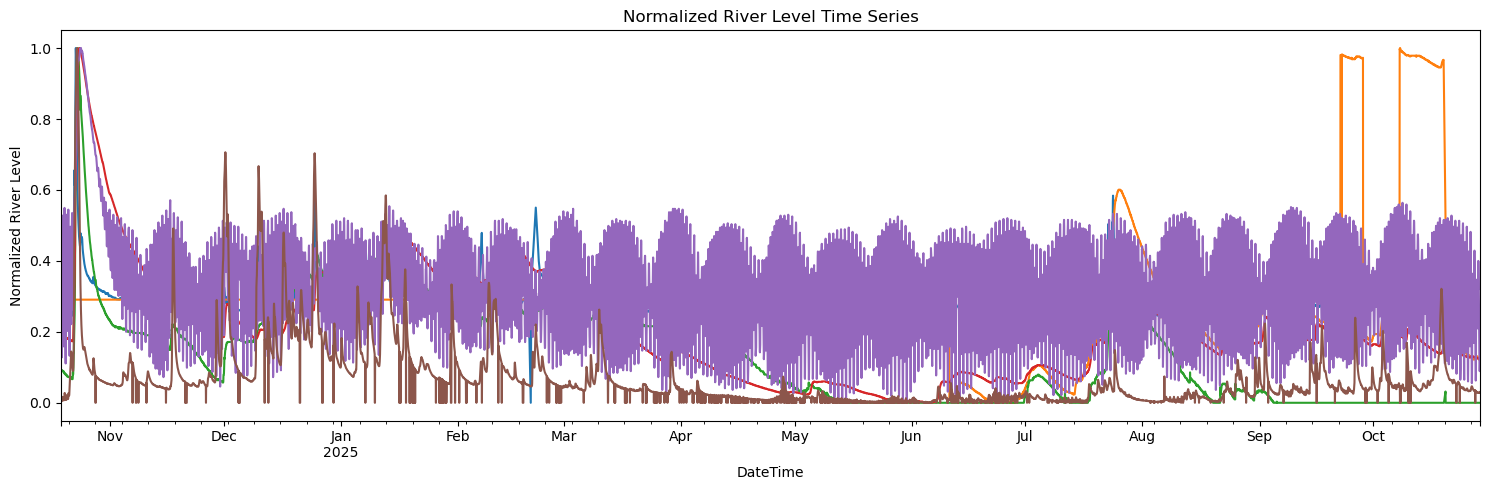


Final shapes: Rainfall (9008, 10), River Level (9008, 6)
Indices aligned: True

SAMPLE DATA (First 5 rows)

Rainfall:
                     Malabog  Calsada  Caguscos  Bato  Buhi  Ombao  Ocampo  \
2024-10-19 01:00:00      0.0      0.0       0.0   0.0   0.0    0.0     0.0   
2024-10-19 02:00:00      0.0      0.0       0.0   0.0   0.0    0.0     0.0   
2024-10-19 03:00:00      0.0      0.0       0.0   0.0   0.0    0.0     0.0   
2024-10-19 04:00:00      0.0      0.0       0.0   0.0   0.0    0.0     0.0   
2024-10-19 05:00:00      0.0      0.0       0.0   0.0   0.0    0.0     0.0   

                     Camaligan  Bagamelon  Sipocot  
2024-10-19 01:00:00        0.0        0.0      0.0  
2024-10-19 02:00:00        0.0        0.0      0.0  
2024-10-19 03:00:00        0.0        0.0      0.0  
2024-10-19 04:00:00        0.0        0.0      0.0  
2024-10-19 05:00:00        0.0        0.0      0.0  

River Level:
                      Calsada      Bato      Buhi     Ombao  Camaligan  \
2024-1

In [13]:
import matplotlib.pyplot as plt

rainfall_norm.plot(figsize=(15,5), legend=False, title="Normalized Rainfall Time Series")
plt.ylabel("Normalized Rainfall")
plt.xlabel("DateTime")
plt.tight_layout()
plt.savefig('rainfall_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

riverlevel_norm.plot(figsize=(15,5), legend=False, title="Normalized River Level Time Series")
plt.ylabel("Normalized River Level")
plt.xlabel("DateTime")
plt.tight_layout()
plt.savefig('riverlevel_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal shapes: Rainfall {rainfall_norm.shape}, River Level {riverlevel_norm.shape}")
print(f"Indices aligned: {(rainfall_norm.index == riverlevel_norm.index).all()}")

print("\n" + "="*50)
print("SAMPLE DATA (First 5 rows)")
print("="*50)
print("\nRainfall:")
print(rainfall_norm.head())
print("\nRiver Level:")
print(riverlevel_norm.head())

In [14]:
print("\n" + "="*70)
print("SAVING CLEANED DATA")
print("="*70)

rainfall_norm.to_csv('rainfall_norm.csv')
riverlevel_norm.to_csv('riverlevel_norm.csv')

print("✓ Saved: rainfall_norm.csv")
print("✓ Saved: riverlevel_norm.csv")


SAVING CLEANED DATA
✓ Saved: rainfall_norm.csv
✓ Saved: riverlevel_norm.csv


## Station MetaData

In [15]:
# Save station metadata (updated)
print("\n" + "="*70)
print("UPDATING STATION METADATA")
print("="*70)

# Your station coordinates
all_station_coords = {
    'Alanao': (122.9262, 13.91536),
    'Sipocot': (122.975, 13.77142),
    'Bagamelon': (123.0242, 13.60066),
    'Camaligan': (123.1633, 13.61951),
    'Balongay': (123.1287, 13.71349),
    'Ocampo': (123.3819, 13.55661),
    'Buhi': (123.509, 13.4337),
    'Bato': (123.3645, 13.35348),
    'Ombao': (123.2413, 13.47482),
    'Malabog': (123.6653, 13.16487),
    'Calsada': (123.5105, 13.25111),
    'Caguscos': (123.3312, 13.34848),
}

# Get actual station names from cleaned data
rainfall_stations = rainfall_norm.columns.tolist()
riverlevel_stations = riverlevel_norm.columns.tolist()

# Create coordinate arrays
rainfall_coords = []
for station in rainfall_stations:
    if station in all_station_coords:
        lon, lat = all_station_coords[station]
        rainfall_coords.append([lon, lat])
    else:
        print(f"⚠️  Warning: No coordinates for rainfall station '{station}'")

riverlevel_coords = []
for station in riverlevel_stations:
    if station in all_station_coords:
        lon, lat = all_station_coords[station]
        riverlevel_coords.append([lon, lat])
    else:
        print(f"⚠️  Warning: No coordinates for river level station '{station}'")

rainfall_coords = np.array(rainfall_coords)
riverlevel_coords = np.array(riverlevel_coords)


UPDATING STATION METADATA


In [16]:
# Save
np.save('rainfall_coords.npy', rainfall_coords)
np.save('riverlevel_coords.npy', riverlevel_coords)

print(f"✓ Rainfall stations: {len(rainfall_stations)}")
print(f"✓ River level stations: {len(riverlevel_stations)}")
print("✓ Saved: rainfall_coords.npy")
print("✓ Saved: riverlevel_coords.npy")

# Summary
print("\n" + "="*70)
print("PREPROCESSING COMPLETE - DATA READY")
print("="*70)
print("\n✅ All NaN values handled")
print("✅ All infinities removed")
print("✅ Data properly normalized (0-1)")
print(f"✅ Rainfall: {rainfall_norm.shape[0]} hours × {rainfall_norm.shape[1]} stations")
print(f"✅ River level: {riverlevel_norm.shape[0]} hours × {riverlevel_norm.shape[1]} stations")
print("\n➡️  Next: Redo spatial gridding with cleaned data")
print("="*70)

✓ Rainfall stations: 10
✓ River level stations: 6
✓ Saved: rainfall_coords.npy
✓ Saved: riverlevel_coords.npy

PREPROCESSING COMPLETE - DATA READY

✅ All NaN values handled
✅ All infinities removed
✅ Data properly normalized (0-1)
✅ Rainfall: 9008 hours × 10 stations
✅ River level: 9008 hours × 6 stations

➡️  Next: Redo spatial gridding with cleaned data


# DEM Preprocess

## Dependencies


DEM PREPROCESSING
✓ DEM loaded
  DEM shape: (4649, 5142)
  DEM data type: float32


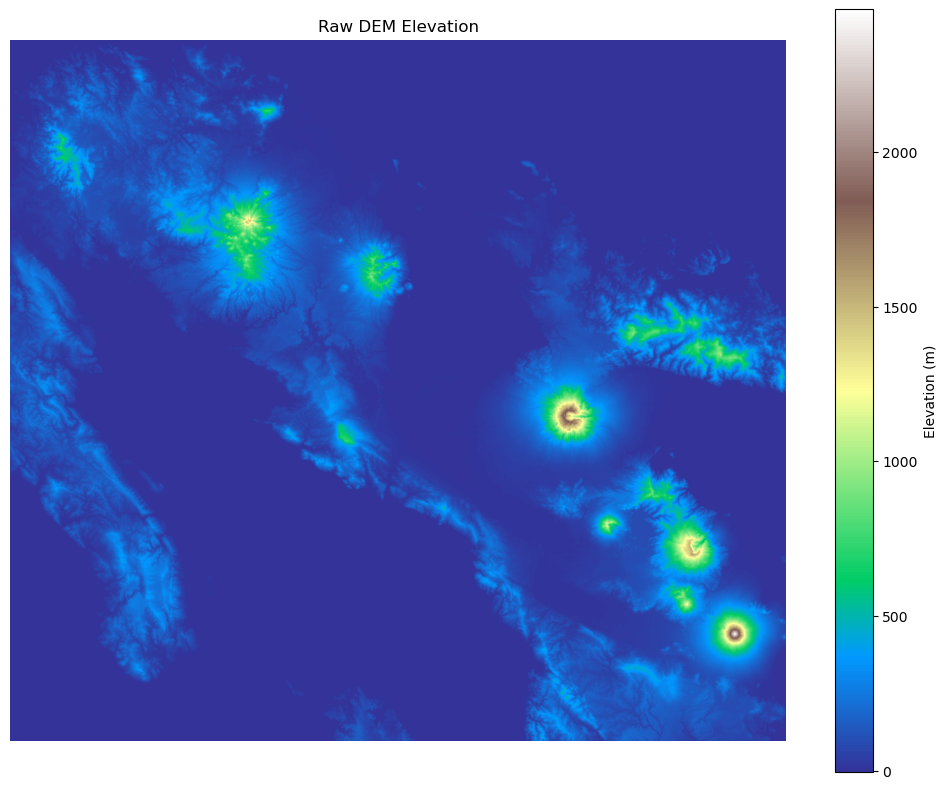

In [17]:
print("\n" + "="*50)
print("DEM PREPROCESSING")
print("="*50)

import rasterio
import numpy as np

dem_path = 'Bicol-DEM.tif'

with rasterio.open(dem_path) as src:
    dem_array = src.read(1)
    dem_meta = src.meta
    nodata_val = src.nodata if src.nodata is not None else -9999

print(f"✓ DEM loaded")
print(f"  DEM shape: {dem_array.shape}")
print(f"  DEM data type: {dem_array.dtype}")

plt.figure(figsize=(10, 8))
plt.imshow(dem_array, cmap='terrain')
plt.colorbar(label='Elevation (m)')
plt.title('Raw DEM Elevation')
plt.axis('off')
plt.tight_layout()
plt.savefig('dem_raw.png', dpi=150, bbox_inches='tight')
plt.show()

## No Data Handling

In [18]:
dem_array = np.where(dem_array == nodata_val, np.nan, dem_array)

print(f"\n✓ NoData values handled")
print(f"  NaN pixels: {np.sum(np.isnan(dem_array))}")


✓ NoData values handled
  NaN pixels: 0


## Downsampling

In [19]:
from scipy.ndimage import zoom

TARGET_SIZE = 256  # Target grid size (256x256 is manageable)
# Calculate downsampling factors
downsample_factor_h = TARGET_SIZE / dem_array.shape[0]
downsample_factor_w = TARGET_SIZE / dem_array.shape[1]

print(f"\n⚠️  DEM is too large ({dem_array.shape}), downsampling...")
print(f"  Target size: {TARGET_SIZE} x {TARGET_SIZE}")
print(f"  Downsample factors: {downsample_factor_h:.4f} x {downsample_factor_w:.4f}")

# Replace NaN with mean for interpolation
dem_temp = dem_array.copy()
dem_temp[np.isnan(dem_temp)] = np.nanmean(dem_array)

# Zoom (bilinear interpolation)
dem_downsampled = zoom(dem_temp, (downsample_factor_h, downsample_factor_w), order=1)

print(f"✓ DEM downsampled to: {dem_downsampled.shape}")


⚠️  DEM is too large ((4649, 5142)), downsampling...
  Target size: 256 x 256
  Downsample factors: 0.0551 x 0.0498
✓ DEM downsampled to: (256, 256)


## Normalize


✓ DEM normalized
  Original range: -4.50 to 2393.01 meters
  Normalized range: 0.000 to 1.000


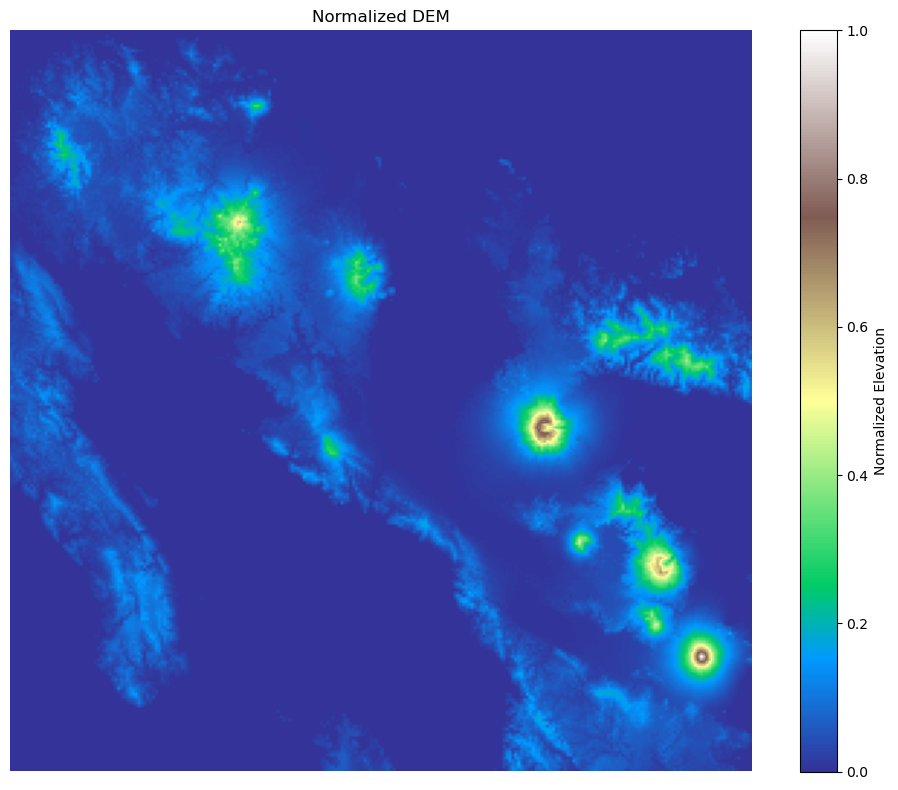

In [20]:
dem_min = np.nanmin(dem_downsampled)
dem_max = np.nanmax(dem_downsampled)
dem_norm = (dem_downsampled - dem_min) / (dem_max - dem_min)

print(f"\n✓ DEM normalized")
print(f"  Original range: {dem_min:.2f} to {dem_max:.2f} meters")
print(f"  Normalized range: {np.nanmin(dem_norm):.3f} to {np.nanmax(dem_norm):.3f}")

plt.figure(figsize=(10, 8))
plt.imshow(dem_norm, cmap='terrain')
plt.colorbar(label='Normalized Elevation')
plt.title('Normalized DEM')
plt.axis('off')
plt.tight_layout()
plt.savefig('dem_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

## Export

In [21]:
np.save('dem_norm.npy', dem_norm)

print("\n✓ Saved: dem_norm.npy")


✓ Saved: dem_norm.npy


In [22]:
print("\n" + "="*70)
print("PREPROCESSING COMPLETE - FILES READY FOR STEP 1")
print("="*70)
print("\nGenerated files:")
print("  1. rainfall_norm.csv       - Normalized rainfall time series")
print("  2. riverlevel_norm.csv     - Normalized river level time series")
print("  3. station_metadata.csv    - Station coordinates")
print("  4. dem_norm.npy            - Normalized DEM array")
print("\nVisualization files:")
print("  - rainfall_timeseries.png")
print("  - riverlevel_timeseries.png")
print("  - dem_raw.png")
print("  - dem_normalized.png")
print("\n✓ Ready for Spatial Gridding")
print("="*70)


PREPROCESSING COMPLETE - FILES READY FOR STEP 1

Generated files:
  1. rainfall_norm.csv       - Normalized rainfall time series
  2. riverlevel_norm.csv     - Normalized river level time series
  3. station_metadata.csv    - Station coordinates
  4. dem_norm.npy            - Normalized DEM array

Visualization files:
  - rainfall_timeseries.png
  - riverlevel_timeseries.png
  - dem_raw.png
  - dem_normalized.png

✓ Ready for Spatial Gridding


# Spatial Gridding

In [23]:
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

In [24]:
rainfall_norm = pd.read_csv('rainfall_norm.csv', index_col=0, parse_dates=True)
riverlevel_norm = pd.read_csv('riverlevel_norm.csv', index_col=0, parse_dates=True)
dem_norm = np.load('dem_norm.npy')

rainfall_coords = np.load('rainfall_coords.npy')
riverlevel_coords = np.load('riverlevel_coords.npy')

In [25]:
print(f"DEM shape: {dem_norm.shape}")
print(f"Rainfall data shape: {rainfall_norm.shape}")
print(f"River level data shape: {riverlevel_norm.shape}")
print(f"Rainfall coordinates shape: {rainfall_coords.shape}")
print(f"River level coordinates shape: {riverlevel_coords.shape}")

DEM shape: (256, 256)
Rainfall data shape: (9008, 10)
River level data shape: (9008, 6)
Rainfall coordinates shape: (10, 2)
River level coordinates shape: (6, 2)


In [26]:
def create_spatial_grid(station_values, station_coords, dem_shape, method='cubic'):
    """
    Interpolate station point data to spatial grid matching DEM
    
    Args:
        station_values: array (n_stations,) - values at each station
        station_coords: array (n_stations, 2) - [lon, lat]
        dem_shape: tuple (height, width) - target grid shape
        method: 'nearest', 'linear', or 'cubic'
    
    Returns:
        grid: array (height, width)
    """
    # Create coordinate grid matching DEM extent
    lon_min, lon_max = station_coords[:, 0].min(), station_coords[:, 0].max()
    lat_min, lat_max = station_coords[:, 1].min(), station_coords[:, 1].max()
    
    # Add buffer (10% on each side)
    lon_buffer = (lon_max - lon_min) * 0.1
    lat_buffer = (lat_max - lat_min) * 0.1
    
    grid_lon = np.linspace(lon_min - lon_buffer, lon_max + lon_buffer, dem_shape[1])
    grid_lat = np.linspace(lat_min - lat_buffer, lat_max + lat_buffer, dem_shape[0])
    grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)
    
    # Interpolate station values to grid
    grid = griddata(
        station_coords, 
        station_values, 
        (grid_lon, grid_lat), 
        method=method,
        fill_value=0.0
    )
    
    return grid

In [27]:
def create_spatiotemporal_grids(time_series_df, station_coords, dem_shape, method='cubic'):
    """
    Convert entire time series from point data to spatial grids
    
    Args:
        time_series_df: DataFrame (timesteps, n_stations)
        station_coords: array (n_stations, 2)
        dem_shape: tuple (height, width)
        method: interpolation method
    
    Returns:
        grids: array (timesteps, height, width)
    """
    n_timesteps = len(time_series_df)
    grids = np.zeros((n_timesteps, dem_shape[0], dem_shape[1]), dtype=np.float32)
    
    print(f"Creating {n_timesteps} spatial grids...")
    
    for t in range(n_timesteps):
        station_values = time_series_df.iloc[t].values
        grids[t] = create_spatial_grid(station_values, station_coords, dem_shape, method)
        
        if (t + 1) % 1000 == 0:
            print(f"  Processed {t + 1}/{n_timesteps} timesteps")
    
    return grids

In [28]:
print("\n" + "="*50)
print("Creating rainfall spatial grids...")
print("="*50)
rainfall_grids = create_spatiotemporal_grids(
    rainfall_norm, 
    rainfall_coords, 
    dem_norm.shape, 
    method='cubic'
)

print("\n" + "="*50)
print("Creating river level spatial grids...")
print("="*50)
riverlevel_grids = create_spatiotemporal_grids(
    riverlevel_norm, 
    riverlevel_coords, 
    dem_norm.shape, 
    method='cubic'
)

print(f"\nRainfall grids shape: {rainfall_grids.shape}")
print(f"River level grids shape: {riverlevel_grids.shape}")


Creating rainfall spatial grids...
Creating 9008 spatial grids...
  Processed 1000/9008 timesteps
  Processed 2000/9008 timesteps
  Processed 3000/9008 timesteps
  Processed 4000/9008 timesteps
  Processed 5000/9008 timesteps
  Processed 6000/9008 timesteps
  Processed 7000/9008 timesteps
  Processed 8000/9008 timesteps
  Processed 9000/9008 timesteps

Creating river level spatial grids...
Creating 9008 spatial grids...
  Processed 1000/9008 timesteps
  Processed 2000/9008 timesteps
  Processed 3000/9008 timesteps
  Processed 4000/9008 timesteps
  Processed 5000/9008 timesteps
  Processed 6000/9008 timesteps
  Processed 7000/9008 timesteps
  Processed 8000/9008 timesteps
  Processed 9000/9008 timesteps

Rainfall grids shape: (9008, 256, 256)
River level grids shape: (9008, 256, 256)


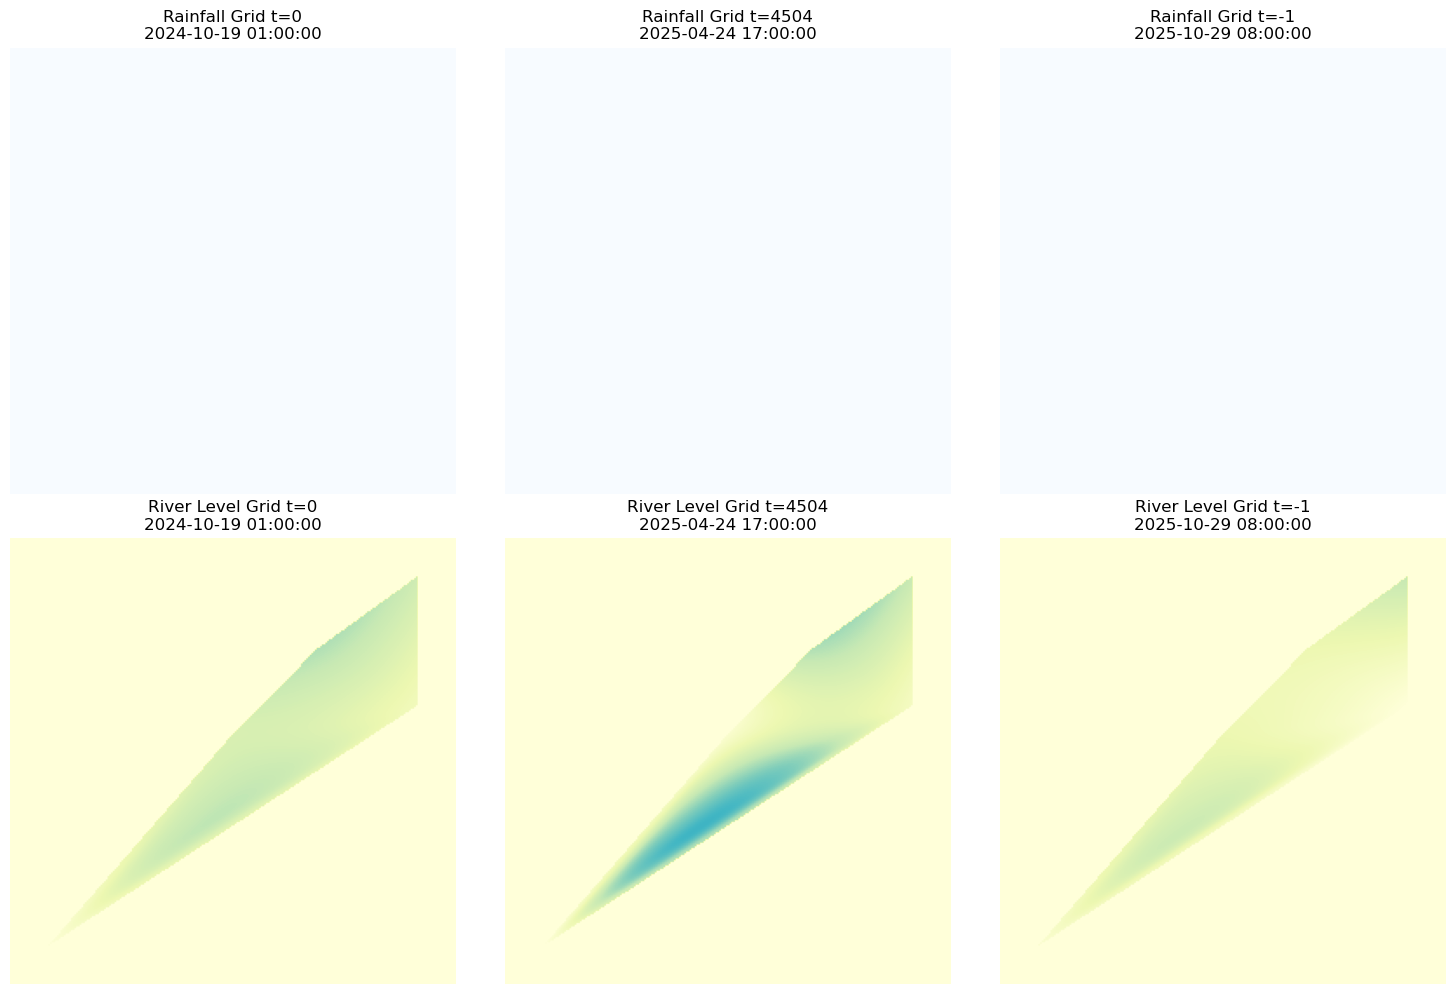

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sample_indices = [0, len(rainfall_grids)//2, -1]

for idx, t in enumerate(sample_indices):
    axes[0, idx].imshow(rainfall_grids[t], cmap='Blues', vmin=0, vmax=1)
    axes[0, idx].set_title(f'Rainfall Grid t={t}\n{rainfall_norm.index[t]}')
    axes[0, idx].axis('off')
    
    axes[1, idx].imshow(riverlevel_grids[t], cmap='YlGnBu', vmin=0, vmax=1)
    axes[1, idx].set_title(f'River Level Grid t={t}\n{riverlevel_norm.index[t]}')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.savefig('spatial_grids_sample.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
print("\nSaving spatial grids...")
np.save('rainfall_grids.npy', rainfall_grids)
np.save('riverlevel_grids.npy', riverlevel_grids)

print("\n✓ Spatial gridding complete!")
print(f"✓ Saved: rainfall_grids.npy {rainfall_grids.shape}")
print(f"✓ Saved: riverlevel_grids.npy {riverlevel_grids.shape}")


Saving spatial grids...

✓ Spatial gridding complete!
✓ Saved: rainfall_grids.npy (9008, 256, 256)
✓ Saved: riverlevel_grids.npy (9008, 256, 256)


# Sequence Generation

In [31]:
import numpy as np
import matplotlib.pyplot as plt

print("="*50)
print("LOADING DATA")
print("="*50)

rainfall_grids = np.load('rainfall_grids.npy')
riverlevel_grids = np.load('riverlevel_grids.npy')
dem_norm = np.load('dem_norm.npy')

print(f"✓ Loaded data shapes:")
print(f"  Rainfall grids: {rainfall_grids.shape}")
print(f"  River level grids: {riverlevel_grids.shape}")
print(f"  DEM: {dem_norm.shape}")

LOADING DATA
✓ Loaded data shapes:
  Rainfall grids: (9008, 256, 256)
  River level grids: (9008, 256, 256)
  DEM: (256, 256)


In [32]:
INPUT_TIMESTEPS = 12  # Use past 12 hours to predict
OUTPUT_TIMESTEPS = 6  # Predict next 6 hours
STRIDE = 6  # INCREASED FROM 1 - Creates fewer sequences to save memory

print(f"\nSequence parameters:")
print(f"  Input timesteps: {INPUT_TIMESTEPS} hours")
print(f"  Output timesteps: {OUTPUT_TIMESTEPS} hours")
print(f"  Stride: {STRIDE}")
print(f"  ⚠️  STRIDE={STRIDE} means we skip some data to reduce memory usage")


Sequence parameters:
  Input timesteps: 12 hours
  Output timesteps: 6 hours
  Stride: 6
  ⚠️  STRIDE=6 means we skip some data to reduce memory usage


In [33]:
def create_sequences_optimized(rainfall_grids, riverlevel_grids, dem_norm, 
                               input_steps, output_steps, stride=1):
    """
    Memory-optimized sequence creation using pre-allocated numpy arrays
    
    Args:
        rainfall_grids: array (T, H, W) - rainfall spatial grids
        riverlevel_grids: array (T, H, W) - river level spatial grids
        dem_norm: array (H, W) - normalized DEM (static)
        input_steps: int - number of past timesteps as input
        output_steps: int - number of future timesteps to predict
        stride: int - sliding window stride
    
    Returns:
        X: array (N, input_steps, H, W, C) - input sequences
        y: array (N, output_steps, H, W, 1) - output sequences
    """
    T, H, W = rainfall_grids.shape
    
    # Calculate number of sequences
    n_sequences = (T - input_steps - output_steps) // stride + 1
    
    print(f"\n" + "="*50)
    print("MEMORY ESTIMATION")
    print("="*50)
    
    # Estimate memory requirements
    X_size_gb = (n_sequences * input_steps * H * W * 3 * 4) / (1024**3)  # 4 bytes per float32
    y_size_gb = (n_sequences * output_steps * H * W * 1 * 4) / (1024**3)
    total_gb = X_size_gb + y_size_gb
    
    print(f"  Number of sequences: {n_sequences}")
    print(f"  Estimated X size: {X_size_gb:.2f} GB")
    print(f"  Estimated y size: {y_size_gb:.2f} GB")
    print(f"  Total memory needed: {total_gb:.2f} GB")
    
    if total_gb > 50:
        print(f"\n  ⚠️  WARNING: This requires {total_gb:.0f} GB of memory!")
        print(f"  Consider increasing STRIDE to reduce sequences")
        user_input = input("  Continue anyway? (yes/no): ").strip().lower()
        if user_input != 'yes':
            print("  Aborting. Please increase STRIDE value.")
            return None, None
    
    print(f"\n" + "="*50)
    print("CREATING SEQUENCES")
    print("="*50)
    print(f"  Total timesteps: {T}")
    print(f"  Input timesteps: {input_steps}")
    print(f"  Output timesteps: {output_steps}")
    print(f"  Stride: {stride}")
    print()
    
    # PRE-ALLOCATE arrays (much more memory efficient than lists!)
    X = np.zeros((n_sequences, input_steps, H, W, 3), dtype=np.float32)
    y = np.zeros((n_sequences, output_steps, H, W, 1), dtype=np.float32)
    
    print("  Arrays allocated. Creating sequences...")
    
    seq_idx = 0
    for i in range(0, T - input_steps - output_steps + 1, stride):
        # Input sequence
        for t in range(input_steps):
            X[seq_idx, t, :, :, 0] = rainfall_grids[i + t]      # Rainfall
            X[seq_idx, t, :, :, 1] = riverlevel_grids[i + t]    # River level
            X[seq_idx, t, :, :, 2] = dem_norm                   # DEM (static)
        
        # Output sequence
        for t in range(output_steps):
            y[seq_idx, t, :, :, 0] = riverlevel_grids[i + input_steps + t]
        
        seq_idx += 1
        
        if seq_idx % 1000 == 0:
            print(f"  Created {seq_idx}/{n_sequences} sequences...")
    
    print(f"\n✓ Sequence creation complete!")
    print(f"  X shape: {X.shape} (samples, input_steps, H, W, channels)")
    print(f"  y shape: {y.shape} (samples, output_steps, H, W, 1)")
    print(f"  X dtype: {X.dtype}")
    print(f"  y dtype: {y.dtype}")
    
    # Actual memory usage
    X_memory = X.nbytes / (1024**3)  # GB
    y_memory = y.nbytes / (1024**3)  # GB
    print(f"\nActual memory usage:")
    print(f"  X: {X_memory:.2f} GB")
    print(f"  y: {y_memory:.2f} GB")
    print(f"  Total: {X_memory + y_memory:.2f} GB")
    
    return X, y

In [34]:
X, y = create_sequences_optimized(
    rainfall_grids, 
    riverlevel_grids, 
    dem_norm,
    input_steps=INPUT_TIMESTEPS,
    output_steps=OUTPUT_TIMESTEPS,
    stride=STRIDE
)


MEMORY ESTIMATION
  Number of sequences: 1499
  Estimated X size: 13.17 GB
  Estimated y size: 2.20 GB
  Total memory needed: 15.37 GB

CREATING SEQUENCES
  Total timesteps: 9008
  Input timesteps: 12
  Output timesteps: 6
  Stride: 6

  Arrays allocated. Creating sequences...
  Created 1000/1499 sequences...

✓ Sequence creation complete!
  X shape: (1499, 12, 256, 256, 3) (samples, input_steps, H, W, channels)
  y shape: (1499, 6, 256, 256, 1) (samples, output_steps, H, W, 1)
  X dtype: float32
  y dtype: float32

Actual memory usage:
  X: 13.17 GB
  y: 2.20 GB
  Total: 15.37 GB


In [35]:
if X is None or y is None:
    print("\n❌ Sequence creation aborted. Please adjust STRIDE and try again.")
    exit()

In [36]:
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

n_samples = len(X)
train_size = int(n_samples * train_ratio)
val_size = int(n_samples * val_ratio)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print("\n" + "="*50)
print("DATASET SPLITS")
print("="*50)
print(f"Training set:   {X_train.shape[0]:5d} samples ({train_ratio*100:.0f}%)")
print(f"Validation set: {X_val.shape[0]:5d} samples ({val_ratio*100:.0f}%)")
print(f"Test set:       {X_test.shape[0]:5d} samples ({test_ratio*100:.0f}%)")
print(f"{'─'*50}")
print(f"Total:          {n_samples:5d} samples (100%)")


DATASET SPLITS
Training set:    1049 samples (70%)
Validation set:   224 samples (15%)
Test set:         226 samples (15%)
──────────────────────────────────────────────────
Total:           1499 samples (100%)



VISUALIZING SAMPLE SEQUENCES


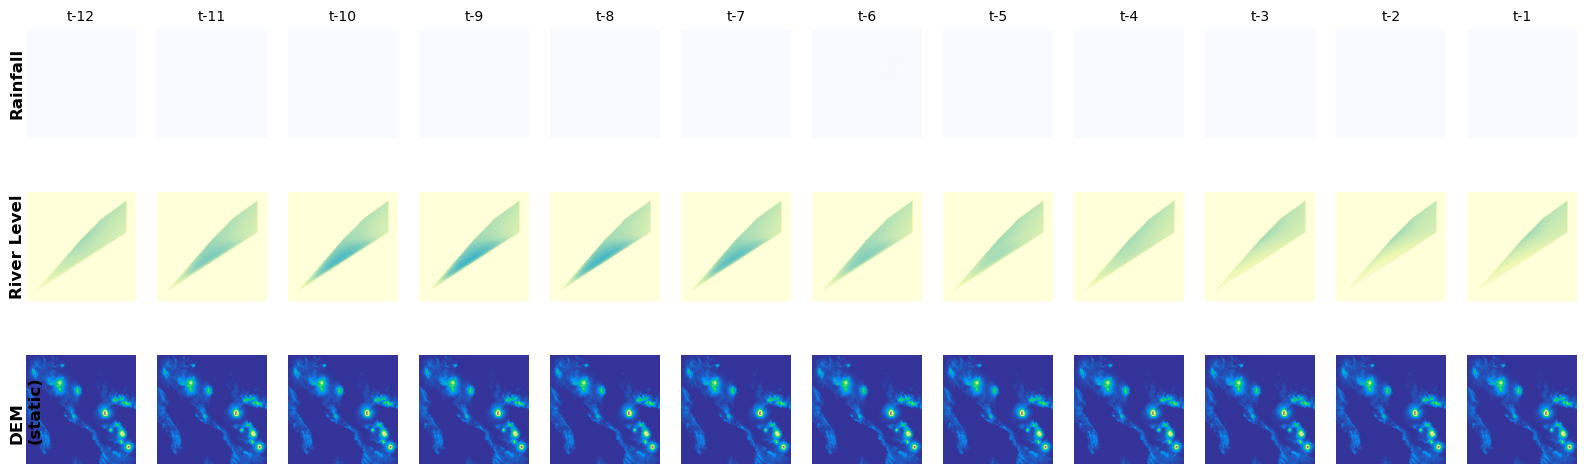

In [37]:
print("\n" + "="*50)
print("VISUALIZING SAMPLE SEQUENCES")
print("="*50)

fig, axes = plt.subplots(3, INPUT_TIMESTEPS, figsize=(20, 6))

sample_idx = min(100, len(X_train) - 1)  # Adjust if fewer samples

for t in range(INPUT_TIMESTEPS):
    # Rainfall
    axes[0, t].imshow(X_train[sample_idx, t, :, :, 0], cmap='Blues', vmin=0, vmax=1)
    axes[0, t].set_title(f't-{INPUT_TIMESTEPS-t}', fontsize=10)
    axes[0, t].axis('off')
    if t == 0:
        axes[0, t].text(-0.15, 0.5, 'Rainfall', transform=axes[0, t].transAxes,
                       fontsize=12, fontweight='bold', va='center', rotation=90)
    
    # River Level
    axes[1, t].imshow(X_train[sample_idx, t, :, :, 1], cmap='YlGnBu', vmin=0, vmax=1)
    axes[1, t].axis('off')
    if t == 0:
        axes[1, t].text(-0.15, 0.5, 'River Level', transform=axes[1, t].transAxes,
                       fontsize=12, fontweight='bold', va='center', rotation=90)
    
    # DEM
    axes[2, t].imshow(X_train[sample_idx, t, :, :, 2], cmap='terrain', vmin=0, vmax=1)
    axes[2, t].axis('off')
    if t == 0:
        axes[2, t].text(-0.15, 0.5, 'DEM\n(static)', transform=axes[2, t].transAxes,
                       fontsize=12, fontweight='bold', va='center', rotation=90)

In [38]:
plt.suptitle(f'Sample Input Sequence (Past {INPUT_TIMESTEPS} hours)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_input_sequence.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: sample_input_sequence.png")

<Figure size 640x480 with 0 Axes>

✓ Saved: sample_input_sequence.png


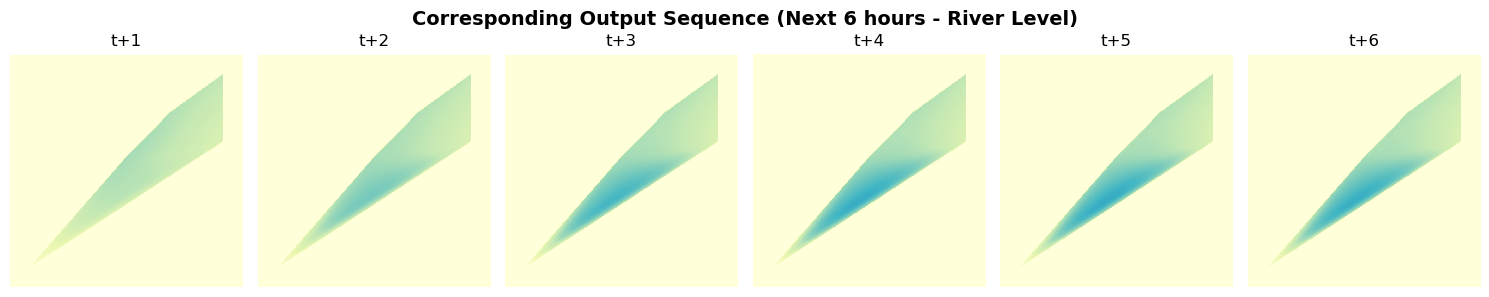

✓ Saved: sample_output_sequence.png


In [39]:
fig, axes = plt.subplots(1, OUTPUT_TIMESTEPS, figsize=(15, 3))

for t in range(OUTPUT_TIMESTEPS):
    axes[t].imshow(y_train[sample_idx, t, :, :, 0], cmap='YlGnBu', vmin=0, vmax=1)
    axes[t].set_title(f't+{t+1}', fontsize=12)
    axes[t].axis('off')

plt.suptitle(f'Corresponding Output Sequence (Next {OUTPUT_TIMESTEPS} hours - River Level)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_output_sequence.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: sample_output_sequence.png")

In [40]:
print("\n" + "="*50)
print("DATA STATISTICS")
print("="*50)

print("\nInput data (X) statistics:")
print(f"  Channel 0 (Rainfall):    min={X[:,:,:,:,0].min():.4f}, max={X[:,:,:,:,0].max():.4f}, mean={X[:,:,:,:,0].mean():.4f}")
print(f"  Channel 1 (River Level): min={X[:,:,:,:,1].min():.4f}, max={X[:,:,:,:,1].max():.4f}, mean={X[:,:,:,:,1].mean():.4f}")
print(f"  Channel 2 (DEM):         min={X[:,:,:,:,2].min():.4f}, max={X[:,:,:,:,2].max():.4f}, mean={X[:,:,:,:,2].mean():.4f}")

print("\nOutput data (y) statistics:")
print(f"  River Level (target):    min={y.min():.4f}, max={y.max():.4f}, mean={y.mean():.4f}")


DATA STATISTICS

Input data (X) statistics:
  Channel 0 (Rainfall):    min=-0.4677, max=1.4267, mean=0.0013
  Channel 1 (River Level): min=-0.0611, max=1.0943, mean=0.0371
  Channel 2 (DEM):         min=0.0000, max=1.0000, mean=0.0327

Output data (y) statistics:
  River Level (target):    min=-0.0611, max=1.0943, mean=0.0371


In [41]:
print("\n" + "="*50)
print("SAVING DATASETS")
print("="*50)

np.save('X_train.npy', X_train)
np.save('y_train.npy', y_train)
np.save('X_val.npy', X_val)
np.save('y_val.npy', y_val)
np.save('X_test.npy', X_test)
np.save('y_test.npy', y_test)

print("✓ Saved: X_train.npy")
print("✓ Saved: y_train.npy")
print("✓ Saved: X_val.npy")
print("✓ Saved: y_val.npy")
print("✓ Saved: X_test.npy")
print("✓ Saved: y_test.npy")

# Summary
print("\n" + "="*50)
print("SEQUENCE GENERATION COMPLETE")
print("="*50)
print("\n✓ All sequences created and saved successfully!")
print("✓ Training, validation, and test sets ready")
print("✓ Visualizations saved")
print(f"\n📊 Final dataset sizes:")
print(f"  Training: {len(X_train)} sequences")
print(f"  Validation: {len(X_val)} sequences")
print(f"  Test: {len(X_test)} sequences")
print("="*50)


SAVING DATASETS
✓ Saved: X_train.npy
✓ Saved: y_train.npy
✓ Saved: X_val.npy
✓ Saved: y_val.npy
✓ Saved: X_test.npy
✓ Saved: y_test.npy

SEQUENCE GENERATION COMPLETE

✓ All sequences created and saved successfully!
✓ Training, validation, and test sets ready
✓ Visualizations saved

📊 Final dataset sizes:
  Training: 1049 sequences
  Validation: 224 sequences
  Test: 226 sequences


# ConvLSTM Model

In [42]:
!pip install tensorflow
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Load datasets to get dimensions
print("="*50)
print("LOADING DATA TO GET DIMENSIONS")
print("="*50)

X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_val = np.load('X_val.npy')
y_val = np.load('y_val.npy')
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

print("Dataset shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  y_val: {y_val.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")

Defaulting to user installation because normal site-packages is not writeable
LOADING DATA TO GET DIMENSIONS
Dataset shapes:
  X_train: (1049, 12, 256, 256, 3)
  y_train: (1049, 6, 256, 256, 1)
  X_val: (224, 12, 256, 256, 3)
  y_val: (224, 6, 256, 256, 1)
  X_test: (226, 12, 256, 256, 3)
  y_test: (226, 6, 256, 256, 1)


In [43]:
INPUT_TIMESTEPS = X_train.shape[1]
OUTPUT_TIMESTEPS = y_train.shape[1]
HEIGHT = X_train.shape[2]
WIDTH = X_train.shape[3]
INPUT_CHANNELS = X_train.shape[4]

print(f"\nModel configuration:")
print(f"  Input timesteps: {INPUT_TIMESTEPS}")
print(f"  Output timesteps: {OUTPUT_TIMESTEPS}")
print(f"  Spatial dimensions: {HEIGHT} x {WIDTH}")
print(f"  Input channels: {INPUT_CHANNELS}")


Model configuration:
  Input timesteps: 12
  Output timesteps: 6
  Spatial dimensions: 256 x 256
  Input channels: 3


In [44]:
def build_convlstm_model(input_shape, output_timesteps):
    """
    Build ConvLSTM model for spatiotemporal river level prediction
    
    Architecture:
    - ConvLSTM2D layers to capture spatiotemporal patterns
    - Batch Normalization for training stability
    - TimeDistributed Conv2D for multi-step prediction
    
    Args:
        input_shape: (timesteps, height, width, channels)
        output_timesteps: number of future timesteps to predict
    
    Returns:
        model: Keras model
    """
    
    print("\n" + "="*50)
    print("BUILDING MODEL ARCHITECTURE")
    print("="*50)
    
    inputs = layers.Input(shape=input_shape)
    
    # Encoder: ConvLSTM layers to capture spatiotemporal patterns
    print("Adding ConvLSTM2D layer 1 (64 filters)...")
    x = layers.ConvLSTM2D(
        filters=64,
        kernel_size=(3, 3),
        padding='same',
        return_sequences=True,
        activation='relu',
        name='convlstm_1'
    )(inputs)
    x = layers.BatchNormalization()(x)
    
    print("Adding ConvLSTM2D layer 2 (64 filters)...")
    x = layers.ConvLSTM2D(
        filters=64,
        kernel_size=(3, 3),
        padding='same',
        return_sequences=True,
        activation='relu',
        name='convlstm_2'
    )(x)
    x = layers.BatchNormalization()(x)
    
    print("Adding ConvLSTM2D layer 3 (32 filters)...")
    x = layers.ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        return_sequences=False,  # Output single state
        activation='relu',
        name='convlstm_3'
    )(x)
    x = layers.BatchNormalization()(x)
    
    # Decoder: Generate multi-step predictions
    # Repeat the encoded state for output_timesteps
    print(f"Creating decoder for {output_timesteps} timesteps...")
    x = layers.RepeatVector(output_timesteps)(layers.Flatten()(x))
    x = layers.Reshape((output_timesteps, input_shape[1], input_shape[2], 32))(x)
    
    # TimeDistributed Conv2D to predict each future timestep
    print("Adding TimeDistributed Conv2D layers...")
    x = layers.TimeDistributed(
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        name='conv_decode_1'
    )(x)
    
    x = layers.TimeDistributed(
        layers.Conv2D(16, (3, 3), padding='same', activation='relu'),
        name='conv_decode_2'
    )(x)
    
    # Output layer: predict river level (1 channel)
    print("Adding output layer...")
    outputs = layers.TimeDistributed(
        layers.Conv2D(1, (1, 1), padding='same', activation='sigmoid'),
        name='output'
    )(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    
    return model

In [45]:
print("\n" + "="*50)
print("INITIALIZING MODEL")
print("="*50)

input_shape = (INPUT_TIMESTEPS, HEIGHT, WIDTH, INPUT_CHANNELS)
model = build_convlstm_model(input_shape, OUTPUT_TIMESTEPS)


INITIALIZING MODEL

BUILDING MODEL ARCHITECTURE
Adding ConvLSTM2D layer 1 (64 filters)...
Adding ConvLSTM2D layer 2 (64 filters)...
Adding ConvLSTM2D layer 3 (32 filters)...
Creating decoder for 6 timesteps...
Adding TimeDistributed Conv2D layers...
Adding output layer...


In [46]:
print("\n" + "="*50)
print("COMPILING MODEL")
print("="*50)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', 'mse']
)

print("✓ Model compiled successfully")
print(f"  Optimizer: Adam (lr=0.001)")
print(f"  Loss: Mean Squared Error (MSE)")
print(f"  Metrics: MAE, MSE")


COMPILING MODEL
✓ Model compiled successfully
  Optimizer: Adam (lr=0.001)
  Loss: Mean Squared Error (MSE)
  Metrics: MAE, MSE


In [47]:
print("\n" + "="*50)
print("MODEL SUMMARY")
print("="*50)
model.summary()

# Calculate total parameters
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])

print("\n" + "="*50)
print("MODEL STATISTICS")
print("="*50)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model memory (approx): {total_params * 4 / (1024**2):.2f} MB")


MODEL SUMMARY


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12, 256, 256,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convlstm_1 (ConvLSTM2D)         │ (None, 12, 256, 256,   │       154,624 │
│                                 │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 256, 256,   │           256 │
│ (BatchNormalization)            │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convlstm_2 (ConvLSTM2D)         │ (None, 12, 256, 256,   │       295,168 │
│                                 │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 256, 256,   │           256 │
│ (BatchNormalization)            │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convlstm_3 (ConvLSTM2D)         │ (None, 256, 256, 32)   │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2097152)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 6, 2097152)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 6, 256, 256,    │             0 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_decode_1 (TimeDistributed) │ (None, 6, 256, 256,    │         9,248 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_decode_2 (TimeDistributed) │ (None, 6, 256, 256,    │         4,624 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 6, 256, 256, 1) │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,041 (2.19 MB)

 Trainable params: 574,721 (2.19 MB)

 Non-trainable params: 320 (1.25 KB)


MODEL STATISTICS
Total parameters: 575,041
Trainable parameters: 574,721
Model memory (approx): 2.19 MB


In [48]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("\n" + "="*50)
print("SETTING UP TRAINING CALLBACKS")
print("="*50)

callbacks = [
    ModelCheckpoint(
        'best_convlstm_model.keras',   # extension .keras is enough
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("✓ Callbacks configured:")
print("  1. ModelCheckpoint - Saves best model to 'best_convlstm_model.keras'")
print("  2. EarlyStopping - Stops if no improvement for 15 epochs")
print("  3. ReduceLROnPlateau - Reduces learning rate if plateau detected")


SETTING UP TRAINING CALLBACKS
✓ Callbacks configured:
  1. ModelCheckpoint - Saves best model to 'best_convlstm_model.keras'
  2. EarlyStopping - Stops if no improvement for 15 epochs
  3. ReduceLROnPlateau - Reduces learning rate if plateau detected


In [49]:
try:
    print("\n" + "="*50)
    print("SAVING MODEL ARCHITECTURE")
    print("="*50)
    
    keras.utils.plot_model(
        model,
        to_file='model_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        dpi=150
    )
    print("✓ Saved: model_architecture.png")
except Exception as e:
    print(f"⚠️  Could not save architecture diagram: {e}")
    print("   (This is optional, model is still ready)")


SAVING MODEL ARCHITECTURE
You must install pydot (`pip install pydot`) for `plot_model` to work.
✓ Saved: model_architecture.png


In [50]:
print("\n" + "="*70)
print("MODEL ARCHITECTURE COMPLETE")
print("="*70)
print("\n✓ ConvLSTM model built and compiled successfully!")
print("✓ Model is ready for training")
print("✓ Callbacks configured for optimal training")
print(f"\nModel specifications:")
print(f"  • Input: ({INPUT_TIMESTEPS}, {HEIGHT}, {WIDTH}, {INPUT_CHANNELS})")
print(f"  • Output: ({OUTPUT_TIMESTEPS}, {HEIGHT}, {WIDTH}, 1)")
print(f"  • Parameters: {total_params:,}")
print(f"  • Architecture: 3x ConvLSTM2D + 2x Conv2D decoder")
print("="*70)


MODEL ARCHITECTURE COMPLETE

✓ ConvLSTM model built and compiled successfully!
✓ Model is ready for training
✓ Callbacks configured for optimal training

Model specifications:
  • Input: (12, 256, 256, 3)
  • Output: (6, 256, 256, 1)
  • Parameters: 575,041
  • Architecture: 3x ConvLSTM2D + 2x Conv2D decoder


# Training

In [51]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import json
from datetime import datetime
import os

In [52]:
class MemoryEfficientGenerator(keras.utils.Sequence):
    """
    Custom data generator that loads batches from memory-mapped files
    Extremely memory-efficient - only loads what's needed
    """
    
    def __init__(self, X_path, y_path, batch_size, shuffle=True, **kwargs):
        """
        Args:
            X_path: path to X .npy file
            y_path: path to y .npy file
            batch_size: number of samples per batch
            shuffle: whether to shuffle data at epoch end
            **kwargs: Additional arguments (workers, use_multiprocessing, etc.)
        """
        super().__init__(**kwargs)  # Fix for the warning
        self.X = np.load(X_path, mmap_mode='r')  # Memory-mapped, not loaded
        self.y = np.load(y_path, mmap_mode='r')
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.X))
        
        if self.shuffle:
            np.random.shuffle(self.indices)
    
    def __len__(self):
        """Number of batches per epoch"""
        return int(np.ceil(len(self.X) / self.batch_size))
    
    def __getitem__(self, idx):
        """
        Generate one batch of data
        Only loads batch_size samples into memory at a time
        """
        # Get batch indices
        start_idx = idx * self.batch_size
        end_idx = min((idx + 1) * self.batch_size, len(self.X))
        batch_indices = self.indices[start_idx:end_idx]
        
        # Load only this batch into memory (key to memory efficiency!)
        X_batch = np.array(self.X[batch_indices])
        y_batch = np.array(self.y[batch_indices])
        
        return X_batch, y_batch
    
    def on_epoch_end(self):
        """Shuffle indices after each epoch"""
        if self.shuffle:
            np.random.shuffle(self.indices)

In [53]:
# Training configuration
print("="*50)
print("TRAINING CONFIGURATION")
print("="*50)

BATCH_SIZE = 2  # Small batch for memory efficiency
EPOCHS = 100
INITIAL_LR = 0.001

print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {EPOCHS}")
print(f"  Initial learning rate: {INITIAL_LR}")

# Create data generators
print("\n" + "="*50)
print("CREATING DATA GENERATORS")
print("="*50)

train_generator = MemoryEfficientGenerator(
    X_path='X_train.npy',
    y_path='y_train.npy',
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_generator = MemoryEfficientGenerator(
    X_path='X_val.npy',
    y_path='y_val.npy',
    batch_size=BATCH_SIZE,
    shuffle=False  # Don't shuffle validation
)

print(f"✓ Training generator created: {len(train_generator)} batches/epoch")
print(f"✓ Validation generator created: {len(val_generator)} batches/epoch")

TRAINING CONFIGURATION
  Batch size: 2
  Max epochs: 100
  Initial learning rate: 0.001

CREATING DATA GENERATORS
✓ Training generator created: 525 batches/epoch
✓ Validation generator created: 112 batches/epoch


In [55]:
# Build model
print("\n" + "="*50)
print("BUILDING MODEL")
print("="*50)

def build_convlstm_model(input_shape, output_timesteps):
    """Build memory-efficient ConvLSTM model"""
    inputs = layers.Input(shape=input_shape)
    
    # Smaller model to reduce memory
    x = layers.ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        return_sequences=True,
        activation='relu',
        name='convlstm_1'
    )(inputs)
    x = layers.BatchNormalization()(x)
    
    x = layers.ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        return_sequences=True,
        activation='relu',
        name='convlstm_2'
    )(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.ConvLSTM2D(
        filters=16,
        kernel_size=(3, 3),
        padding='same',
        return_sequences=False,
        activation='relu',
        name='convlstm_3'
    )(x)
    x = layers.BatchNormalization()(x)
    
    # Decoder
    x = layers.RepeatVector(output_timesteps)(layers.Flatten()(x))
    x = layers.Reshape((output_timesteps, input_shape[1], input_shape[2], 16))(x)
    
    x = layers.TimeDistributed(
        layers.Conv2D(16, (3, 3), padding='same', activation='relu'),
        name='conv_decode_1'
    )(x)
    
    x = layers.TimeDistributed(
        layers.Conv2D(8, (3, 3), padding='same', activation='relu'),
        name='conv_decode_2'
    )(x)
    
    outputs = layers.TimeDistributed(
        layers.Conv2D(1, (1, 1), padding='same', activation='sigmoid'),
        name='output'
    )(x)
    
    return models.Model(inputs=inputs, outputs=outputs)

# Load or build model
if os.path.exists('best_convlstm_model.keras'):
    print("\n⚠️  Found existing model: best_convlstm_model.keras")
    user_choice = input("Continue training from this model? (yes/no): ").strip().lower()
    
    if user_choice == 'yes':
        print("✓ Loading existing model...")
        model = keras.models.load_model('best_convlstm_model.keras')
        print("✓ Model loaded")
    else:
        print("✓ Building new model...")
        # Get shape from generator
        sample_X, _ = train_generator[0]
        input_shape = sample_X.shape[1:]  # Remove batch dimension
        output_timesteps = 6  # Your output timesteps
        
        model = build_convlstm_model(input_shape, output_timesteps)
        
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=INITIAL_LR),
            loss='mse',
            metrics=['mae']
        )
        print("✓ New model compiled")
else:
    print("✓ Building new model...")
    # Get shape from generator
    sample_X, _ = train_generator[0]
    input_shape = sample_X.shape[1:]
    output_timesteps = 6
    
    model = build_convlstm_model(input_shape, output_timesteps)
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=INITIAL_LR),
        loss='mse',
        metrics=['mae']
    )
    print("✓ New model compiled")

total_params = model.count_params()
print(f"\nModel parameters: {total_params:,}")


BUILDING MODEL

⚠️  Found existing model: best_convlstm_model.keras


Continue training from this model? (yes/no):  no


✓ Building new model...
✓ New model compiled

Model parameters: 145,825


In [56]:
# Setup callbacks
callbacks = [
    ModelCheckpoint(
        'best_convlstm_model.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("\n" + "="*50)
print("CALLBACKS CONFIGURED")
print("="*50)
print("✓ ModelCheckpoint: Save best model")
print("✓ EarlyStopping: Stop if no improvement for 15 epochs")
print("✓ ReduceLROnPlateau: Reduce LR on plateau")


CALLBACKS CONFIGURED
✓ ModelCheckpoint: Save best model
✓ EarlyStopping: Stop if no improvement for 15 epochs
✓ ReduceLROnPlateau: Reduce LR on plateau


In [57]:
"""
DIAGNOSTIC SCRIPT - Find Why Training Has NaN
Run this to identify the problem
"""

import numpy as np

print("="*70)
print("DIAGNOSING NaN ISSUE")
print("="*70)

# Check training data
print("\n1. CHECKING TRAINING DATA...")
X_train = np.load('X_train.npy', mmap_mode='r')
y_train = np.load('y_train.npy', mmap_mode='r')

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# Check for NaN
print("\n2. CHECKING FOR NaN VALUES...")
print("Checking first 100 samples (to avoid loading everything)...")

has_nan_X = False
has_nan_y = False
has_inf_X = False
has_inf_y = False

for i in range(min(100, len(X_train))):
    X_sample = np.array(X_train[i])
    y_sample = np.array(y_train[i])
    
    if np.any(np.isnan(X_sample)):
        print(f"  ❌ Found NaN in X_train sample {i}")
        has_nan_X = True
        break
    
    if np.any(np.isnan(y_sample)):
        print(f"  ❌ Found NaN in y_train sample {i}")
        has_nan_y = True
        break
    
    if np.any(np.isinf(X_sample)):
        print(f"  ❌ Found Inf in X_train sample {i}")
        has_inf_X = True
        break
    
    if np.any(np.isinf(y_sample)):
        print(f"  ❌ Found Inf in y_train sample {i}")
        has_inf_y = True
        break

if not (has_nan_X or has_nan_y or has_inf_X or has_inf_y):
    print("  ✓ No NaN or Inf found in first 100 samples")

# Check value ranges
print("\n3. CHECKING VALUE RANGES...")
print("Loading first 10 samples for detailed analysis...")

X_samples = np.array(X_train[:10])
y_samples = np.array(y_train[:10])

print(f"\nX_train statistics:")
print(f"  Min: {X_samples.min():.6f}")
print(f"  Max: {X_samples.max():.6f}")
print(f"  Mean: {X_samples.mean():.6f}")
print(f"  Std: {X_samples.std():.6f}")

print(f"\ny_train statistics:")
print(f"  Min: {y_samples.min():.6f}")
print(f"  Max: {y_samples.max():.6f}")
print(f"  Mean: {y_samples.mean():.6f}")
print(f"  Std: {y_samples.std():.6f}")

# Check if data is all zeros
print("\n4. CHECKING FOR ALL-ZERO DATA...")
if X_samples.max() == 0 and X_samples.min() == 0:
    print("  ❌ X_train is ALL ZEROS!")
else:
    print("  ✓ X_train has variation")

if y_samples.max() == 0 and y_samples.min() == 0:
    print("  ❌ y_train is ALL ZEROS!")
else:
    print("  ✓ y_train has variation")

# Check normalization
print("\n5. CHECKING NORMALIZATION...")
if X_samples.min() < 0 or X_samples.max() > 1:
    print(f"  ⚠️  X_train NOT properly normalized (should be 0-1)")
    print(f"     Range: {X_samples.min():.3f} to {X_samples.max():.3f}")
else:
    print("  ✓ X_train properly normalized (0-1)")

if y_samples.min() < 0 or y_samples.max() > 1:
    print(f"  ⚠️  y_train NOT properly normalized (should be 0-1)")
    print(f"     Range: {y_samples.min():.3f} to {y_samples.max():.3f}")
else:
    print("  ✓ y_train properly normalized (0-1)")

# Check channel-by-channel
print("\n6. CHECKING EACH INPUT CHANNEL...")
for ch in range(X_samples.shape[-1]):
    channel_data = X_samples[:, :, :, :, ch]
    print(f"\nChannel {ch}:")
    print(f"  Min: {channel_data.min():.6f}")
    print(f"  Max: {channel_data.max():.6f}")
    print(f"  Mean: {channel_data.mean():.6f}")
    print(f"  Has NaN: {np.any(np.isnan(channel_data))}")
    print(f"  Has Inf: {np.any(np.isinf(channel_data))}")
    
    if channel_data.std() < 1e-6:
        print(f"  ⚠️  WARNING: Channel has very low variance (might be constant)")

# Summary
print("\n" + "="*70)
print("DIAGNOSIS SUMMARY")
print("="*70)

issues = []

if has_nan_X or has_nan_y:
    issues.append("❌ CRITICAL: Data contains NaN values")
    
if has_inf_X or has_inf_y:
    issues.append("❌ CRITICAL: Data contains Inf values")

if X_samples.max() == 0:
    issues.append("❌ CRITICAL: Input data is all zeros")
    
if y_samples.max() == 0:
    issues.append("❌ CRITICAL: Output data is all zeros")

if X_samples.min() < 0 or X_samples.max() > 1.1:
    issues.append("⚠️  Data not properly normalized")

if len(issues) == 0:
    print("\n✓ No obvious data issues found!")
    print("\nPossible causes of NaN during training:")
    print("  1. Learning rate too high (try 0.0001 instead of 0.001)")
    print("  2. Gradient explosion in ConvLSTM layers")
    print("  3. Batch contains edge cases not in first 100 samples")
    print("\nRecommended fixes:")
    print("  - Reduce learning rate to 0.0001")
    print("  - Add gradient clipping")
    print("  - Check full dataset (not just first 100 samples)")
else:
    print("\n⚠️  FOUND ISSUES:")
    for issue in issues:
        print(f"  {issue}")
    
    print("\nYou need to fix these before training can work!")

print("="*70)

DIAGNOSING NaN ISSUE

1. CHECKING TRAINING DATA...

X_train shape: (1049, 12, 256, 256, 3)
y_train shape: (1049, 6, 256, 256, 1)

2. CHECKING FOR NaN VALUES...
Checking first 100 samples (to avoid loading everything)...
  ✓ No NaN or Inf found in first 100 samples

3. CHECKING VALUE RANGES...
Loading first 10 samples for detailed analysis...

X_train statistics:
  Min: -0.055134
  Max: 1.000000
  Mean: 0.023039
  Std: 0.065286

y_train statistics:
  Min: 0.000000
  Max: 0.584704
  Mean: 0.035111
  Std: 0.090166

4. CHECKING FOR ALL-ZERO DATA...
  ✓ X_train has variation
  ✓ y_train has variation

5. CHECKING NORMALIZATION...
  ⚠️  X_train NOT properly normalized (should be 0-1)
     Range: -0.055 to 1.000
  ✓ y_train properly normalized (0-1)

6. CHECKING EACH INPUT CHANNEL...

Channel 0:
  Min: -0.055134
  Max: 0.458309
  Mean: 0.001480
  Has NaN: False
  Has Inf: False

Channel 1:
  Min: 0.000000
  Max: 0.584704
  Mean: 0.034941
  Has NaN: False
  Has Inf: False

Channel 2:
  Min: 0.

In [ ]:
# Training
print("\n" + "="*70)
print("STARTING TRAINING (GENERATOR MODE)")
print("="*70)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"\nMemory-efficient mode: Data loaded batch-by-batch")
print(f"You can stop training anytime:")
print(f"  - In Jupyter: Use 'Interrupt Kernel' button (⏹️) or Kernel > Interrupt")
print(f"  - In Terminal: Press Ctrl+C")
print()

history = None  # Initialize history variable

try:
    history = model.fit(
        train_generator,  # Generator instead of X_train
        epochs=EPOCHS,
        validation_data=val_generator,  # Generator instead of X_val
        callbacks=callbacks,
        verbose=1
    )
    
    print("\n" + "="*70)
    print("TRAINING COMPLETE")
    print("="*70)
    print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Total epochs trained: {len(history.history['loss'])}")
    
except KeyboardInterrupt:
    print("\n" + "="*70)
    print("TRAINING INTERRUPTED BY USER (Ctrl+C)")
    print("="*70)
    print("✓ Best model saved: best_convlstm_model.keras")
    print("\nYou can resume training by running this script again!")
    
except Exception as e:
    print("\n" + "="*70)
    print("TRAINING INTERRUPTED")
    print("="*70)
    print(f"Reason: {type(e).__name__}")
    print("✓ Best model saved: best_convlstm_model.keras")
    print("\nYou can resume training by running this script again!")

# Check if training completed at least one epoch
if history is None or len(history.history.get('loss', [])) == 0:
    print("\n⚠️  Training was stopped before completing any epochs.")
    print("✓ Model architecture saved, but no training history available.")
    print("\nTo resume training, simply run this script again.")
    print("="*70)
else:
    # Save training history
    history_dict = {
        'loss': [float(x) for x in history.history['loss']],
        'val_loss': [float(x) for x in history.history['val_loss']],
        'mae': [float(x) for x in history.history['mae']],
        'val_mae': [float(x) for x in history.history['val_mae']],
    }

    with open('training_history.json', 'w') as f:
        json.dump(history_dict, f, indent=2)

    print("\n✓ Training history saved")

# Plot training history
if history is not None and len(history.history.get('loss', [])) > 0:
    print("\n" + "="*50)
    print("GENERATING TRAINING PLOTS")
    print("="*50)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='orange')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss (MSE)', fontsize=12)
    axes[0].set_title('Model Loss Over Time', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2, color='blue')
    axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2, color='orange')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('MAE', fontsize=12)
    axes[1].set_title('Mean Absolute Error Over Time', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("✓ Saved: training_history.png")

    # Evaluate on test set (using generator)
    print("\n" + "="*50)
    print("EVALUATING ON TEST SET")
    print("="*50)

    test_generator = MemoryEfficientGenerator(
        X_path='X_test.npy',
        y_path='y_test.npy',
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    test_results = model.evaluate(test_generator, verbose=1)
    test_loss = test_results[0]
    test_mae = test_results[1]

    print(f"\nTest Set Performance:")
    print(f"  Loss (MSE): {test_loss:.6f}")
    print(f"  MAE: {test_mae:.6f}")
    print(f"  RMSE: {np.sqrt(test_loss):.6f}")

    test_metrics = {
        'test_loss': float(test_loss),
        'test_mae': float(test_mae),
        'test_rmse': float(np.sqrt(test_loss)),
        'final_train_loss': float(history.history['loss'][-1]),
        'final_val_loss': float(history.history['val_loss'][-1]),
        'best_val_loss': float(min(history.history['val_loss'])),
        'total_epochs': len(history.history['loss'])
    }

    with open('test_metrics.json', 'w') as f:
        json.dump(test_metrics, f, indent=2)

    print("\n✓ Test metrics saved")

    # Performance assessment
    print("\n" + "="*70)
    print("TRAINING SUMMARY")
    print("="*70)

    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_val_loss = min(history.history['val_loss'])

    print(f"\nBest Performance:")
    print(f"  Best epoch: {best_epoch}/{len(history.history['loss'])}")
    print(f"  Best validation loss: {best_val_loss:.6f}")
    print(f"  Test MAE: {test_mae:.6f}")

    if test_mae < 0.05:
        print("\n✅ EXCELLENT: MAE < 0.05")
    elif test_mae < 0.10:
        print("\n✅ GOOD: MAE < 0.10")
    elif test_mae < 0.15:
        print("\n⚠️  ACCEPTABLE: MAE < 0.15")
    else:
        print("\n⚠️  NEEDS IMPROVEMENT: MAE > 0.15")

    print("\n" + "="*70)
    print("TRAINING PIPELINE COMPLETE")
    print("="*70)
    print("\n✓ Best model: best_convlstm_model.keras")
    print("✓ Training history: training_history.json")
    print("✓ Test metrics: test_metrics.json")
    print("✓ Training plot: training_history.png")
    print("="*70)


STARTING TRAINING (GENERATOR MODE)
Start time: 2025-11-18 15:48:42

Memory-efficient mode: Data loaded batch-by-batch
You can stop training anytime:
  - In Jupyter: Use 'Interrupt Kernel' button (⏹️) or Kernel > Interrupt
  - In Terminal: Press Ctrl+C

Epoch 1/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - loss: 0.0211 - mae: 0.0587
Epoch 1: val_loss improved from None to 0.00419, saving model to best_convlstm_model.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 4893s 9s/step - loss: 0.0049 - mae: 0.0203 - val_loss: 0.0042 - val_mae: 0.0275 - learning_rate: 0.0010
Epoch 2/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.0013 - mae: 0.0123
Epoch 2: val_loss improved from 0.00419 to 0.00056, saving model to best_convlstm_model.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 4670s 9s/step - loss: 0.0010 - mae: 0.0105 - val_loss: 5.6431e-04 - val_mae: 0.0095 - learning_rate: 0.0010
Epoch 3/100
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - loss: 6.4579e-04 - mae: 0.0076
Epoch 3: val_loss did not improve from 0.000